# Step 2 – Data cleaning and transformation ##

In this step I’m moving from exploration to preparation. The goal is to take the raw audio dataset and produce a clean, consistent set of features that are ready for clustering, while staying as close as possible to the patterns I saw in Step 1.

## Goals: ##

* Drop clearly non-informative or redundant columns (for example, `Unnamed: 0` and one of `release_date` or `age`).
* Keep the topic score columns plus a single time-related feature as the main inputs for clustering.
* Apply minimal cleaning for missing values so that the feature matrix is usable but not overengineered.
* Standardize the numeric features so no single column dominates the clustering just because of its scale.
* Save the cleaned and transformed data to disk so the clustering notebook can focus only on modeling.

## Import packages and load data ##

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

train_path = "../data/train.csv"
train = pd.read_csv(train_path)

train.head()

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


## Handle missing values ##

There are no missing values as shown in Step 1.

## Minimal cleaning: drop columns ##

EDA has shown there are no null values.

In [2]:
df = train.copy()

# Drop index-like column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Keep age and drop release_date, since they encode the same information
if "release_date" in df.columns and "age" in df.columns:
    df = df.drop(columns=["release_date"])

df.head()

,artist_name,track_name,genre,lyrics,len,dating,violence,world/life,night/time,shake the audience,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,mukesh,mohabbat bhi jhoothi,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,0.000598,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,frankie laine,i believe,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,0.001284,0.001284,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,johnnie ray,cry,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,pérez prado,patricia,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,0.001548,0.021500,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,giorgos papadopoulos,apopse eida oneiro,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,0.001350,0.001350,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


From Step 1, it was clear that `Unnamed: 0` behaves like an index rather than a meaningful feature, and that `release_date` and `age` are just two versions of the same time information. I also saw that `len` describes how long the lyrics are but does not directly capture a specific lyrical theme. In this step, I drop `Unnamed: 0` entirely, keep `age` as my time-related feature while dropping `release_date`, and leave `len` out of the clustering feature set.

I specifically chose not to use len as a clustering feature because it mainly captures how long the lyrics are, not what themes they contain. Since my goal is to cluster songs based on lyrical topics and time (`age`), including len could create clusters that are driven by length rather than by meaningful differences in content.


These choices keep the features focused on the topic scores and a single time signal, and avoid giving the model duplicate or loosely related signals that could distract from the thematic structure I’m trying to uncover.


In [10]:
df = train.copy()

# Drop index-like column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Keep age and drop release_date
if "release_date" in df.columns and "age" in df.columns:
    df = df.drop(columns=["release_date"])

df.head()

,artist_name,track_name,genre,lyrics,len,dating,violence,world/life,night/time,shake the audience,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,mukesh,mohabbat bhi jhoothi,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,0.000598,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,frankie laine,i believe,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,0.001284,0.001284,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,johnnie ray,cry,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,pérez prado,patricia,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,0.001548,0.021500,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,giorgos papadopoulos,apopse eida oneiro,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,0.001350,0.001350,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


In [11]:
metadata_cols = ["artist_name", "track_name", "genre", "lyrics", "topic"]
metadata_cols = [c for c in metadata_cols if c in df.columns]

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

feature_cols = [
    c for c in numeric_cols
    if c not in metadata_cols
]

# Treat len as context and remove it from clustering features
if "len" in feature_cols:
    feature_cols.remove("len")

feature_cols

['dating',
 'violence',
 'world/life',
 'night/time',
 'shake the audience',
 'family/gospel',
 'romantic',
 'communication',
 'obscene',
 'music',
 'movement/places',
 'light/visual perceptions',
 'family/spiritual',
 'sadness',
 'feelings',
 'age']

## Standardize the features ##

In [12]:
from sklearn.preprocessing import StandardScaler

X = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.39170138, -0.30575713, -0.69905223, -0.50726467, -0.41371342,
         0.75801213, -0.29765053,  1.70876189, -0.53271589, -0.16845878,
        -0.51136164, -0.54058414, -0.46161638,  1.38505521,  1.20272179,
         2.17668459],
       [ 0.27551381, -0.12087232,  1.87239888, -0.50113711, -0.3968501 ,
         0.23738332, -0.44680505, -0.68831541, -0.52893448,  0.46996389,
        -0.50387328,  1.82770771,  0.52848985, -0.7072628 , -0.4146499 ,
         2.17668459],
       [-0.35022374, -0.64706308, -0.68643995, -0.48785274, -0.36029088,
        -0.3401431 ,  1.03601328,  1.58927688, -0.52073651,  2.13814842,
        -0.48763873, -0.51632985, -0.41905407, -0.69905734,  2.71340239,
         2.17668459],
       [ 0.51826893, -0.6539036 , -0.69353637, -0.49877505,  0.10039976,
        -0.36926307,  3.42098744, -0.68590168, -0.52747682, -0.47443589,
         0.8937931 , -0.52997676, -0.44300216,  0.53265247, -0.41096149,
         2.17668459],
       [-0.37735143, -0.65501446,  1

Because the topic scores and `age` are on different scales, clustering directly on the raw values could give some columns more influence just because their ranges are larger. To avoid that, I standardize each feature so it has mean 0 and standard deviation 1. This keeps the focus on relative differences across features rather than absolute scale and should make the clustering step more stable.

## Fit PCA and inspect variance ##

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
explained_cumsum = explained.cumsum()

explained, explained_cumsum

(array([0.10091617, 0.08560938, 0.07930938, 0.07258307, 0.07033862,
        0.06756905, 0.06547666, 0.06530332, 0.06368529, 0.06159889]),
 array([0.10091617, 0.18652555, 0.26583493, 0.338418  , 0.40875663,
        0.47632568, 0.54180234, 0.60710565, 0.67079095, 0.73238984]))

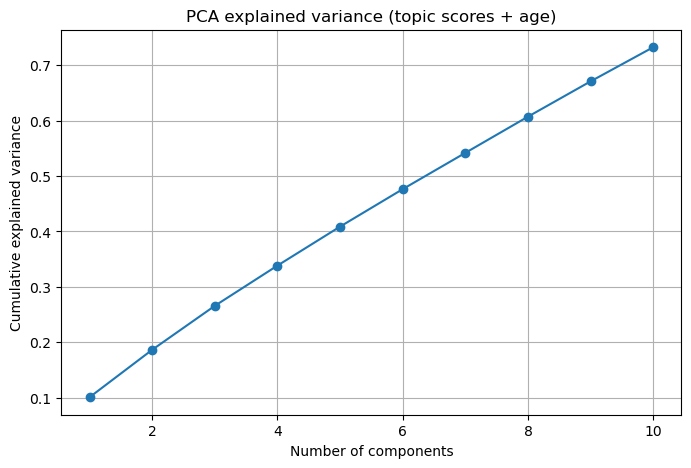

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_cumsum) + 1), explained_cumsum, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance (topic scores + age)")
plt.grid(True)
plt.show()

To see how much structure PCA can capture, I looked at the cumulative explained variance as I added components. The curve rises fairly smoothly from around 0.1 for the first component to a bit over 0.7 by the tenth component, without a clear elbow where the variance suddenly levels off. That pattern suggests that the information in the topic scores and `age` is spread across multiple directions rather than being dominated by just one or two very strong components.

This likely means PCA is still useful as a way to smooth noise and reduce dimensionality somewhat, but it does not give me a tiny set of components (for example, two or three) that explain almost everything. For clustering in the next step, I plan to keep both options open: I can run KMeans directly on the standardized topic features, or I can work in a moderate number of PCA components if that leads to more stable clusters, knowing that I will need more than just a couple of components to capture most of the variation.

## Save cleaned, standardized features ##

In [16]:
# Attach standardized feature values back to the dataframe
df_features = df.copy()
for i, col in enumerate(feature_cols):
    df_features[col] = X_scaled[:, i]

# Save to data folder for the modeling step
df_features.to_csv("../data/cleaned_features.csv", index=False)

## Step 2 summary ##

In this step I turned the raw dataset into a cleaner set of features that are ready for clustering. First, I removed `Unnamed: 0` because it behaves like an index rather than a meaningful variable. I also kept `age` as my single time-related feature and dropped `release_date`, since Step 1 showed that these two columns encode the same information in different forms. In addition, I chose not to use `len` as a clustering feature. It tells me how long the lyrics are, but it does not directly capture a lyrical theme, and my hypotheses focus on topical content and time rather than on lyric length.

Next, I separated out metadata columns such as `artist_name`, `track_name`, `genre`, `lyrics`, and the labeled `topic`. I am keeping these for interpretation and reporting, but I am not feeding them into the clustering algorithm. The remaining numeric columns – the topic scores plus `age` – form my main feature set. I confirmed that there are no missing values in these features, so I did not need to add any imputation or row-dropping logic, which keeps the transformation step simpler.

Finally, I standardized all of the feature columns so that each has mean 0 and standard deviation 1. This prevents any one topic or the `age` feature from dominating the distance calculations purely due to scale differences. I also used PCA as a diagnostic to understand how variation is spread across components, but I decided to run clustering directly on the standardized topic scores plus `age` rather than on a separate PCA representation. The result of this step is a `cleaned_features.csv` file that contains the original metadata along with standardized versions of the features I plan to use for clustering in Step 3.